# loc vs disp spatial current ($G_s$) — deterministic, lattice propagator, $L=1,2$

Two discretizations of the same conserved **spatial** current, fed the lattice overlap propagator
$D_m^{-1}$ (`prop_deter_L<L>`), deterministic trace:

- **loc** (`jj_local_deter`): on-site bare Pauli, $G_s=$ `s1`+`s2` in `corr_deter_local_L{1,2}`.
- **disp** (`jj_disp_deter`): displaced/link current $W^{wz}/\kappa$ (Eqs. 3.33-3.35 / $\kappa$),
  insertion-diagonal over spatial links with weight `link_volume` $=\ell\ell^*$; key `sp` in
  `corr_deter_disp_L{1,2}`. Reproduces Eq.(4.28) $G_s$ via the triangle identity.

Both $\to$ the CFT $G_s$ (Eq. 4.28, $\Delta=2$); they differ only by lattice (operator) artifacts,
which shrink as $L$ grows. (Run `tmp_lat_claude.sh` for loc and `tmp_disp_claude.sh` for disp first.)

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
ESN  = dir1 + 'data_free_vmRe0.000000vmIm0.000000/'
at_cft = 0.2
Nt_cft = 128
Delta_cft = 2.0

def cft_shape(t):
    return np.exp(-Delta_cft*t) * (1.0 - np.exp(-t))**(-2.0*Delta_cft)

def load_Vpp(corrdir, proj, origin='t0_0', k=0):
    # h0/<origin>/<proj>/Vpp ; proj='s1','s2','s3' (loc) or 'sp' (disp).
    path = ESN + corrdir + '/corr.' + str(k) + '.h5'
    with h5py.File(path, 'r') as f:
        key = 'h0/' + origin + '/' + proj + '/Vpp'
        return f[key+'/real'][()] + 1j*f[key+'/imag'][()]

tag = ''   # '' = lattice (corr_deter_{local,disp}_L*) ; 'cont_' = continuum propagator
def locG_s(L):
    cd = 'corr_deter_local_%sL%d' % (tag, L)
    return (load_Vpp(cd, 's1') + load_Vpp(cd, 's2')).real
def dispG_s(L):
    return load_Vpp('corr_deter_disp_%sL%d' % (tag, L), 'sp').real

In [ ]:
# |G_s|: loc (s1+s2) vs disp (sp) vs Eq.(4.28), L=1,2
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
ref = 5

plt.figure()
for L in [1, 2]:
    try:
        gl = locG_s(L); plt.plot(t, gl[dt], 'o-',  ms=3, label='loc s1+s2  L=%d' % L)
    except (OSError, KeyError): print('missing loc L=%d' % L)
    try:
        gd = dispG_s(L); plt.plot(t, gd[dt], 's--', ms=3, label='disp sp  L=%d' % L)
    except (OSError, KeyError): print('missing disp L=%d' % L)
# CFT G_s shape, anchored to loc L=1
gl1 = locG_s(1); A = gl1[ref] / cft_shape(t[ref-1])
plt.plot(t, A*cft_shape(t), 'k-', label='Eq.(4.28) shape')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|G_s|$')
plt.title('lattice $L=1,2$: $|G_s|$ loc vs disp vs Eq.(4.28)'); plt.legend(fontsize=8)
plt.savefig('comp_loc_disp_Gs_lat.pdf', bbox_inches='tight')

In [ ]:
# disp/loc ratio (flat => same shape)
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft

plt.figure()
for L in [1, 2]:
    try:
        plt.plot(t, dispG_s(L)[dt] / locG_s(L)[dt], '.-', label='disp/loc  L=%d' % L)
    except (OSError, KeyError): continue
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel('disp / loc')
plt.title('disp/loc ratio (flat $\\Rightarrow$ same shape)'); plt.legend()
plt.savefig('comp_loc_disp_ratio_lat.pdf', bbox_inches='tight')

L=1: overall factor loc/disp =  1.7864  (matched at dt=5)
L=2: overall factor loc/disp =  1.7902  (matched at dt=5)


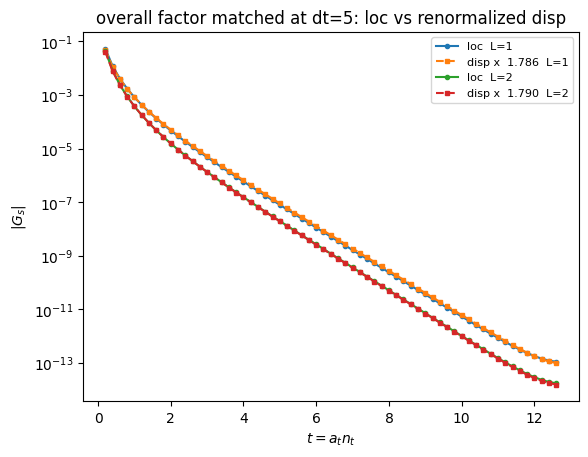

In [3]:
# "Fix the overall factor": loc (on-site bare sigma) and disp (displaced Wilson link W/kappa) are two
# DISCRETIZATIONS of the same current, so they differ by a relative lattice renormalization (an O(1)
# Z-factor) -- the CFT fixes shapes & inter-channel ratios, NOT the absolute scale of one lattice
# operator.  The clean fix is to renormalize to a common point: match disp to loc at one separation.
# (Decomposition: the sign is the clean Dirac-i convention (i^2=-1 in W_d); the magnitude ~1.9 is the
#  renormalization + e^a/triangle geometry.  Residual after matching = displaced-vs-on-site lattice
#  artifact, which shrinks with L.)
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
ref = 5

plt.figure()
for L in [1, 2]:
    try:
        gl = locG_s(L); gd = dispG_s(L)
    except (OSError, KeyError):
        print('missing L=%d' % L); continue
    c = gl[ref] / gd[ref]                       # matching constant (the overall factor, incl. sign)
    print('L=%d: overall factor loc/disp = % .4f  (matched at dt=%d)' % (L, c, ref))
    plt.plot(t, gl[dt],   'o-',  ms=3, label='loc  L=%d' % L)
    plt.plot(t, c*gd[dt], 's--', ms=3, label='disp x % .3f  L=%d' % (c, L))
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|G_s|$')
plt.title('overall factor matched at dt=%d: loc vs renormalized disp' % ref)
plt.legend(fontsize=8); plt.savefig('comp_loc_disp_matched_lat.pdf', bbox_inches='tight')

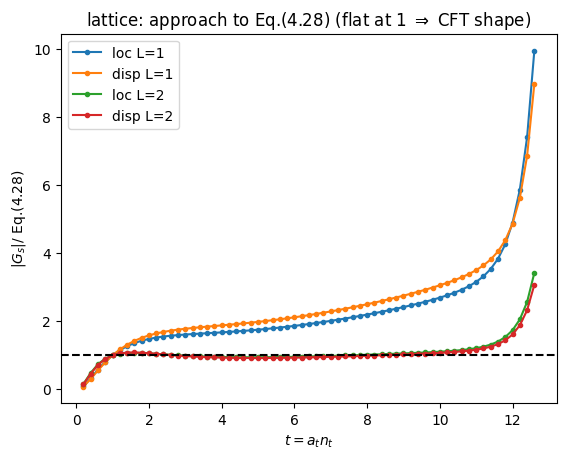

In [4]:
# Approach to CFT: each estimator / Eq.(4.28) shape (own amplitude match), should flatten as L grows
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5

plt.figure()
for L in [1, 2]:
    for name, g in [('loc', locG_s), ('disp', dispG_s)]:
        try:
            y = g(L).real
        except (OSError, KeyError):
            continue
        A = y[ref] / cft_shape(t[ref-1])
        plt.plot(t, y[dt] / (A*cft_shape(t)), '.-', label='%s L=%d' % (name, L))
plt.axhline(1.0, color='k', ls='dashed')
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|G_s| / $ Eq.(4.28)')
plt.title('lattice: approach to Eq.(4.28) (flat at 1 $\\Rightarrow$ CFT shape)')
plt.legend(); plt.savefig('comp_loc_disp_ratioCFT_lat.pdf', bbox_inches='tight')

In [5]:
# signs + magnitudes at a fixed separation (loc/disp normalizations differ: dual_areas vs link_volume)
for L in [1, 2]:
    try:
        gl, gd = locG_s(L), dispG_s(L)
        print('L=%d  loc G_s[5]=% .4e   disp sp[5]=% .4e   disp/loc=% .4f' %
              (L, gl[5], gd[5], gd[5]/gl[5]))
    except (OSError, KeyError) as e:
        print('L=%d missing (%s)' % (L, e))

L=1  loc G_s[5]= 8.2599e-04   disp sp[5]= 4.6238e-04   disp/loc= 0.5598
L=2  loc G_s[5]= 3.7924e-04   disp sp[5]= 2.1184e-04   disp/loc= 0.5586
